In [90]:
import kagglehub

# Descargamos el Data Set de kaggle
path = kagglehub.dataset_download("rounakbanik/pokemon")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pokemon' dataset.
Path to dataset files: /kaggle/input/pokemon


# **Limpieza de Datos**

In [91]:
# Importamos las bibliotecas necesarias

import pandas as pd
import numpy as np

df = pd.read_csv("/kaggle/input/pokemon/pokemon.csv")   # Convertimos el csv descargado a df de pandas (Dirección de la descarga)
df.head()                                               # Revisamos la estructura del DF con .head()

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,against_grass,against_ground,against_ice,against_normal,against_poison,against_psychic,against_rock,against_steel,against_water,attack,base_egg_steps,base_happiness,base_total,capture_rate,classfication,defense,experience_growth,height_m,hp,japanese_name,name,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,49,5120,70,318,45,Seed Pokémon,49,1059860,0.7,45,Fushigidaneフシギダネ,Bulbasaur,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,62,5120,70,405,45,Seed Pokémon,63,1059860,1.0,60,Fushigisouフシギソウ,Ivysaur,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,0.25,1.0,2.0,1.0,1.0,2.0,1.0,1.0,0.5,100,5120,70,625,45,Seed Pokémon,123,1059860,2.0,80,Fushigibanaフシギバナ,Venusaur,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,2.0,0.5,1.0,1.0,1.0,2.0,0.5,2.0,52,5120,70,309,45,Lizard Pokémon,43,1059860,0.6,39,Hitokageヒトカゲ,Charmander,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,0.50,2.0,0.5,1.0,1.0,1.0,2.0,0.5,2.0,64,5120,70,405,45,Flame Pokémon,58,1059860,1.1,58,Lizardoリザード,Charmeleon,88.1,5,80,65,80,fire,NaN,19.0,1,0


## **Selección de características**

In [92]:
# Visualizamos las columnas que se requerirán para el análisis

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 41 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   abilities          801 non-null    object 
 1   against_bug        801 non-null    float64
 2   against_dark       801 non-null    float64
 3   against_dragon     801 non-null    float64
 4   against_electric   801 non-null    float64
 5   against_fairy      801 non-null    float64
 6   against_fight      801 non-null    float64
 7   against_fire       801 non-null    float64
 8   against_flying     801 non-null    float64
 9   against_ghost      801 non-null    float64
 10  against_grass      801 non-null    float64
 11  against_ground     801 non-null    float64
 12  against_ice        801 non-null    float64
 13  against_normal     801 non-null    float64
 14  against_poison     801 non-null    float64
 15  against_psychic    801 non-null    float64
 16  against_rock       801 non

In [93]:
# Copiamos el dataframe solamente con las características que utilizaremos

df_poke = df[['name', 'abilities', 'type1', 'type2', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_total',
              'capture_rate', 'base_egg_steps', 'base_happiness', 'height_m', 'weight_kg', 'is_legendary', 'generation',]].copy()
df_poke.head()

,name,abilities,type1,type2,hp,attack,defense,sp_attack,sp_defense,speed,base_total,capture_rate,base_egg_steps,base_happiness,height_m,weight_kg,is_legendary,generation
0,Bulbasaur,"['Overgrow', 'Chlorophyll']",grass,poison,45,49,49,65,65,45,318,45,5120,70,0.7,6.9,0,1
1,Ivysaur,"['Overgrow', 'Chlorophyll']",grass,poison,60,62,63,80,80,60,405,45,5120,70,1.0,13.0,0,1
2,Venusaur,"['Overgrow', 'Chlorophyll']",grass,poison,80,100,123,122,120,80,625,45,5120,70,2.0,100.0,0,1
3,Charmander,"['Blaze', 'Solar Power']",fire,NaN,39,52,43,60,50,65,309,45,5120,70,0.6,8.5,0,1
4,Charmeleon,"['Blaze', 'Solar Power']",fire,NaN,58,64,58,80,65,80,405,45,5120,70,1.1,19.0,0,1


## **Eliminación de duplicados**

In [94]:
# Revisamos si existen duplicados

df_poke.duplicated().sum()

np.int64(0)

Como no existen duplicados en este dataset, pasemos al siguiente paso

## **Manejo de filas con nulos**

In [95]:
# Revisamos si existen nulos en cada columna

df_poke.isnull().sum()

,0
name,0
abilities,0
type1,0
type2,384
hp,0
attack,0
defense,0
sp_attack,0
sp_defense,0
speed,0


Comencemos con las varibles 'height_m' y 'weight_kg'. <br>
El peso y altura contienen los mismos nulos, revisemos si son de los mismos pokémon

In [96]:
poke_hw_null = df_poke[(df_poke['height_m'].isnull()) & (df_poke['weight_kg'].isnull())]
poke_hw_null[['name', 'height_m', 'weight_kg']]

,name,height_m,weight_kg
18,Rattata,NaN,NaN
19,Raticate,NaN,NaN
25,Raichu,NaN,NaN
26,Sandshrew,NaN,NaN
27,Sandslash,NaN,NaN
36,Vulpix,NaN,NaN
37,Ninetales,NaN,NaN
49,Diglett,NaN,NaN
50,Dugtrio,NaN,NaN
51,Meowth,NaN,NaN


In [97]:
poke_hw_null.shape[0]

20

Como podemos observar, los mismos 20 pokemon tienen nulos tanto en altura y en peso. <br> <br>
Por lo que en este caso en específico es necesario rellenarlos con sus valores reales y no <br>
con medias ni medianas, ya que estos valores varian mucho por pokémon.

In [98]:
# Crear diccionarios separados para altura y peso

alturas = {
    'Rattata': 0.3, 'Raticate': 0.7, 'Raichu': 0.8,
    'Sandshrew': 0.6, 'Sandslash': 1.0, 'Vulpix': 0.6,
    'Ninetales': 1.1, 'Diglett': 0.2, 'Dugtrio': 0.7,
    'Meowth': 0.4, 'Persian': 1.0, 'Geodude': 0.4,
    'Graveler': 1.0, 'Golem': 1.4, 'Grimer': 0.9,
    'Muk': 1.2, 'Exeggutor': 2.0, 'Marowak': 1.0,
    'Hoopa': 0.5, 'Lycanroc': 0.8
}

pesos = {
    'Rattata': 3.5, 'Raticate': 18.5, 'Raichu': 30.0,
    'Sandshrew': 12.0, 'Sandslash': 29.5, 'Vulpix': 9.9,
    'Ninetales': 19.9, 'Diglett': 0.8, 'Dugtrio': 33.3,
    'Meowth': 4.2, 'Persian': 32.0, 'Geodude': 20.0,
    'Graveler': 105.0, 'Golem': 300.0, 'Grimer': 30.0,
    'Muk': 30.0, 'Exeggutor': 120.0, 'Marowak': 45.0,
    'Hoopa': 9.0, 'Lycanroc': 25.0
}

# Rellenar nulos con map
df_poke['height_m'] = df_poke['height_m'].fillna(df_poke['name'].map(alturas))
df_poke['weight_kg'] = df_poke['weight_kg'].fillna(df_poke['name'].map(pesos))

In [99]:
# Comprobar que ya no hay alturas y pesos nulos
poke_hw_null = df_poke[(df_poke['height_m'].isnull()) & (df_poke['weight_kg'].isnull())]
print(f"Pokémon con nulos restantes: {len(poke_hw_null)}")

Pokémon con nulos restantes: 0


Por último, pasemos a rellenar los nulos en el segundo tipo con 'None'

In [100]:
df_poke['type2'] = df_poke['type2'].fillna('None')

In [101]:
df_poke.head(15)  # Podemos observar los cambios hechos en cuanto al manejo de nulos en las primeras 15 filas.

,name,abilities,type1,type2,hp,attack,defense,sp_attack,sp_defense,speed,base_total,capture_rate,base_egg_steps,base_happiness,height_m,weight_kg,is_legendary,generation
0,Bulbasaur,"['Overgrow', 'Chlorophyll']",grass,poison,45,49,49,65,65,45,318,45,5120,70,0.7,6.9,0,1
1,Ivysaur,"['Overgrow', 'Chlorophyll']",grass,poison,60,62,63,80,80,60,405,45,5120,70,1.0,13.0,0,1
2,Venusaur,"['Overgrow', 'Chlorophyll']",grass,poison,80,100,123,122,120,80,625,45,5120,70,2.0,100.0,0,1
3,Charmander,"['Blaze', 'Solar Power']",fire,None,39,52,43,60,50,65,309,45,5120,70,0.6,8.5,0,1
4,Charmeleon,"['Blaze', 'Solar Power']",fire,None,58,64,58,80,65,80,405,45,5120,70,1.1,19.0,0,1
5,Charizard,"['Blaze', 'Solar Power']",fire,flying,78,104,78,159,115,100,634,45,5120,70,1.7,90.5,0,1
6,Squirtle,"['Torrent', 'Rain Dish']",water,None,44,48,65,50,64,43,314,45,5120,70,0.5,9.0,0,1
7,Wartortle,"['Torrent', 'Rain Dish']",water,None,59,63,80,65,80,58,405,45,5120,70,1.0,22.5,0,1
8,Blastoise,"['Torrent', 'Rain Dish']",water,None,79,103,120,135,115,78,630,45,5120,70,1.6,85.5,0,1
9,Caterpie,"['Shield Dust', 'Run Away']",bug,None,45,30,35,20,20,45,195,255,3840,70,0.3,2.9,0,1


## **Corrección tipos de datos**

In [102]:
# Analizamos cuales columnas nos convienen cambiar mostrando los tipos de datos de cada una
df_poke.dtypes

,0
name,object
abilities,object
type1,object
type2,object
hp,int64
attack,int64
defense,int64
sp_attack,int64
sp_defense,int64
speed,int64


En este caso solamente hay un campo que nos conviene cambiar. <br>
El 'capture_rate' de object a int.

In [103]:
# df_poke['capture_rate'] = df_poke['capture_rate'].astype(int)

**Nota:** Al convertir a int la columna, nos manda un error de literal, ya que hay exactamente una dato que usa una cadena en lugar de un número. "30 (Meteorite)255 (Core)".<br>
Es el único dato con esta distinción.

In [104]:
df_poke['capture_rate'] = df_poke['capture_rate'].str.extract('(\\d+)', expand=False).astype(int)

## **Manejo de valores atípicos (Outliers)**

Creamos boxplots para las variables númericas y así determinar visualmente como se comportan

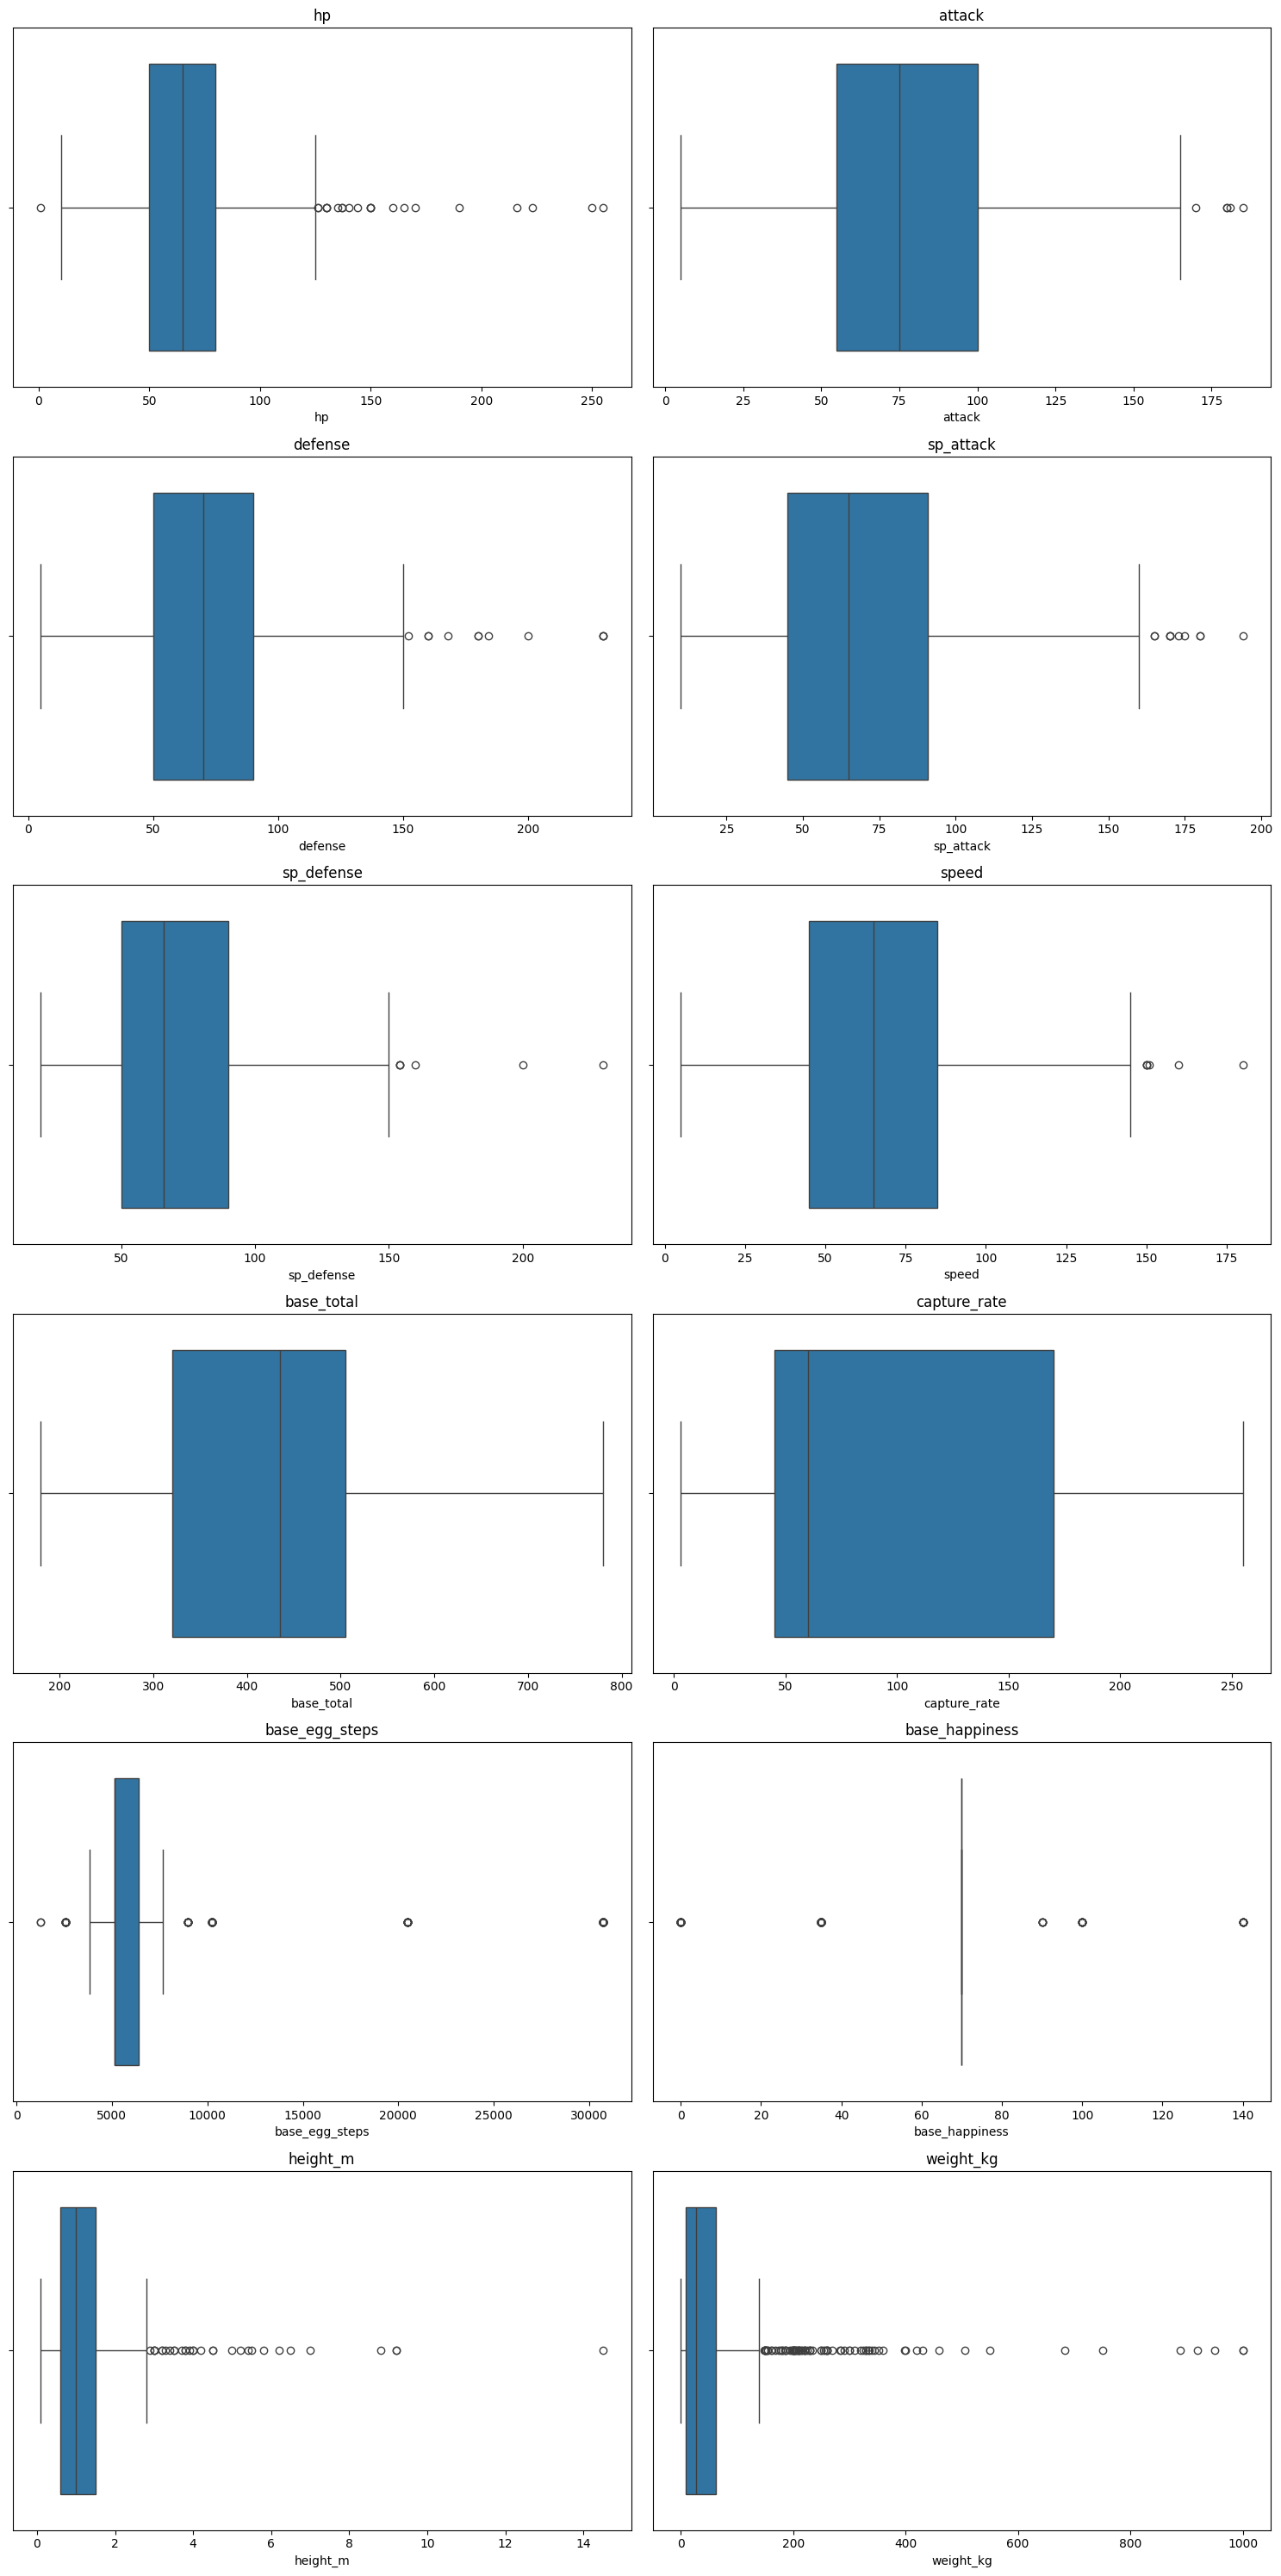

In [105]:
# Importamos las bibliotecas de visualizaciones

import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar las columnas numéricas

cols_num = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_total',
            'capture_rate', 'base_egg_steps', 'base_happiness', 'height_m', 'weight_kg']

fig, ax = plt.subplots(nrows=6, ncols=2, figsize=(15, 30))
fig.subplots_adjust(hspace=0.5)

ax_planos = ax.flatten()

for i, col in enumerate(cols_num):
    sns.boxplot(x=df_poke[col], ax=ax_planos[i])
    ax_planos[i].set_title(col)

plt.tight_layout()

plt.show()

Para este dataset de Pokémon, NO es recomendable eliminar outliers <br>
Los outliers en Pokémon son características legítimas del mundo Pokémon. Por ejemplo:

Mewtwo tiene stats muy altas → no es error

Magikarp tiene stats muy bajas → no es error

Wailord pesa 398 kg → es real

# **Análisis Exploratorio de Datos (EDA)**

**Preguntas de Negocio (Fase de Análisis Exploratorio - EDA):**

1. **Análisis de "Power Creep" (Inflación de poder):** ¿Existe un incremento real en el promedio del Base Stat Total a medida que avanzan las generaciones, o el poder se mantiene balanceado a lo largo del tiempo?

2. **Sinergia y Tipología:** ¿Cuáles son las combinaciones de tipos (Type 1 y Type 2) más raras y cuáles ofrecen la mayor viabilidad estadística (mejor balance entre Defensa/Defensa Especial y HP)?

3. **Economía del Juego (Tasas de captura y crianza):** ¿Qué tanta correlación matemática existe entre la dificultad para atrapar a una criatura (capture_rate), el esfuerzo de crianza (base_egg_steps) y su poder neto (base_total)?

4. **Distribución de Roles Ocultos:** Si analizamos variables como Velocidad (speed) vs. Ataque (attack/sp_attack), ¿qué tipos elementales dominan el rol de atacantes rápidos frente a defensores lentos?

## **1. Análisis de "Power Creep" (Inflación de poder)**

¿Existe un incremento real en el promedio del Base Stat Total a medida que avanzan las generaciones, o el poder se mantiene balanceado a lo largo del tiempo?

In [106]:
# Identificar BST por año

promedio_bst_gen = df_poke.groupby('generation')['base_total'].mean()
promedio_bst_gen

,base_total
generation,
1,416.251656
2,413.180000
3,420.022222
4,451.177570
5,427.038462
6,437.611111
7,448.162500


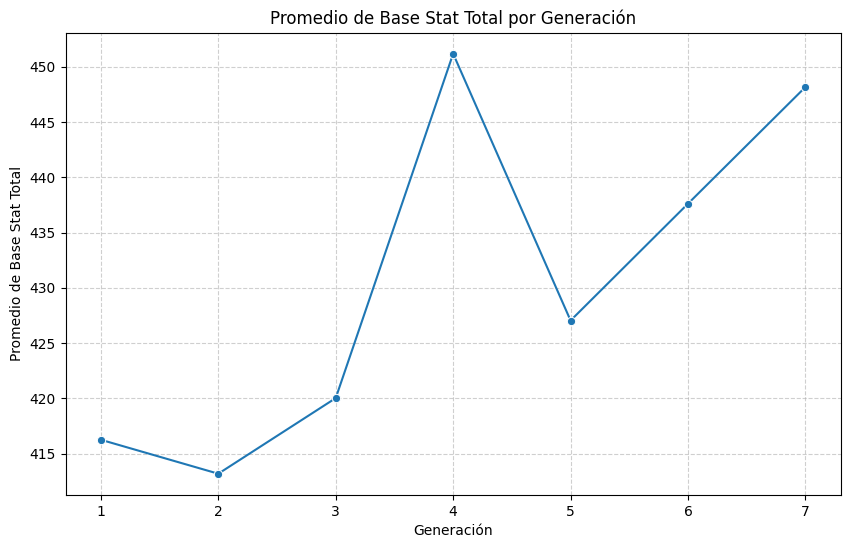

In [107]:
# Visualizar tendencias con gráfica de lineas

plt.figure(figsize=(10, 6))

sns.lineplot(x=promedio_bst_gen.index, y=promedio_bst_gen.values, marker='o')
plt.title('Promedio de Base Stat Total por Generación')
plt.xlabel('Generación')
plt.ylabel('Promedio de Base Stat Total')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**R =** Existe un incremento en un rango de 1ra generación a 4ta generación, especificamente de 3ra a 4ta generación, donde es abrupto el incremento. Esto puede ser debido a la cantidad de pokemones legendarios y megaevoluciones que se introdujeron en esta misma (Con los BST más altos). <br><br>
De 4ta a 5ta generación sufrió un decremento, posiblemente debido a que se introdujeron mayor numero de mosntruos. Y, desde esta ultima, ha ido incrementando linealmente.

## **2. Sinergia y Tipología:**

¿Cuáles son las combinaciones de tipos (Type 1 y Type 2) más raras y cuáles ofrecen la mayor viabilidad estadística (mejor balance entre Defensa/Defensa Especial y HP)?

### *Combinaciones de tipos más raras*

In [108]:
concurrencias = df_poke[['type1', 'type2']].value_counts(ascending=True).reset_index(name='Frecuencia')     # Contamos las concurrencias entre dos tipos

combinaciones_raras = concurrencias[concurrencias['Frecuencia'] < 2]          # Conservamos las más raras ( = 1)
combinaciones_raras

,type1,type2,Frecuencia
0,bug,ghost,1
1,bug,ground,1
2,dragon,electric,1
3,electric,electric,1
4,dragon,fire,1
5,dragon,ice,1
6,dark,ghost,1
7,fire,steel,1
8,ghost,dragon,1
9,fighting,flying,1


Se hizo un conteo de las concurrencias más bajas, es decir, aquellas sólo tienen una combinación de tipos única

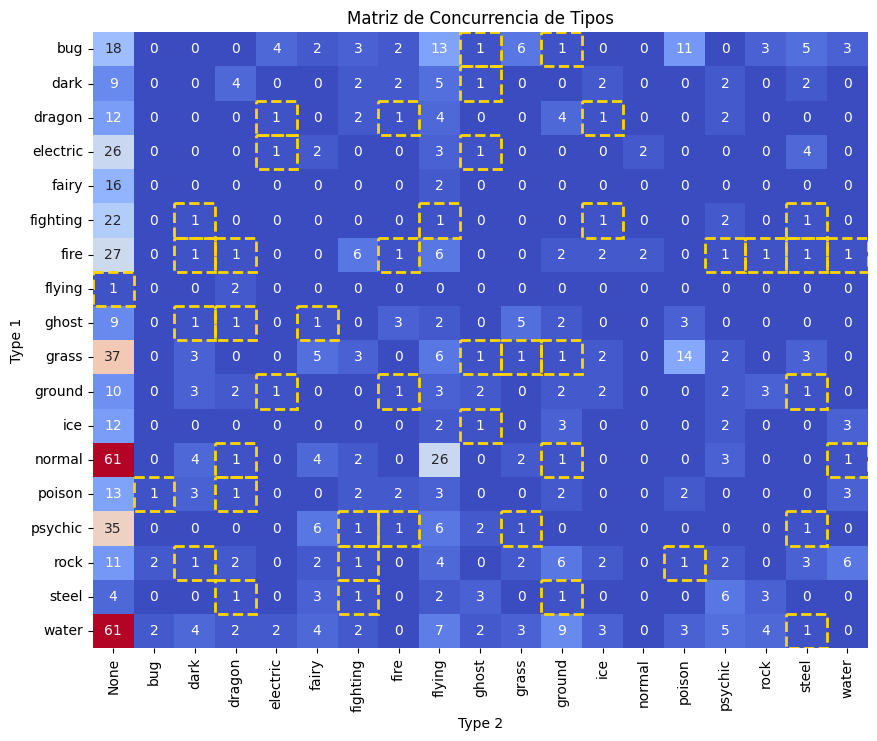

In [109]:
# Visualizamos con un mapa de calor

matriz_concurrencia = pd.crosstab(df_poke['type1'], df_poke['type2'])               # Tabulamos cruzado los tipos

plt.figure(figsize=(10, 8))

sns.heatmap(matriz_concurrencia, annot=True, fmt='d', cmap='coolwarm', cbar=False)  # Definir mapa de calor

cifra_objetivo = 1      # Pokemón con una única combinación de tipos

# Ciclo for anidado para enmarcar aquellas combinaciones
for i in range(matriz_concurrencia.shape[0]):
    for j in range(matriz_concurrencia.shape[1]):
        if matriz_concurrencia.iloc[i, j] == cifra_objetivo:
            rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='gold', lw=2, linestyle='--')
            plt.gca().add_patch(rect)

plt.title('Matriz de Concurrencia de Tipos')
plt.xlabel('Type 2')
plt.ylabel('Type 1')

plt.show()

### *Combinaciones de tipos con mayor viabilidad estadística (mejor balance entre Defensa/Defensa Especial y HP)?*

In [110]:
# Agrupamos por combinación de tipos y calculamos las métricas de defensa

defensa_tipos = df_poke.groupby(['type1', 'type2']).agg(
    conteo=('name', 'count'),
    hp_prom=('hp', 'mean'),
    defense_prom=('defense', 'mean'),
    sp_defense_prom=('sp_defense', 'mean')
).reset_index()

# Filtramos combinaciones con al menos 3 pokémon para que el promedio sea representativo
defensa_tipos = defensa_tipos[defensa_tipos['conteo'] >= 3]

# Viabilidad: promedio general de las 3 stats defensivas
defensa_tipos['viabilidad'] = defensa_tipos[['hp_prom', 'defense_prom', 'sp_defense_prom']].mean(axis=1)

# Balance: qué tan parejas están las 3 stats entre sí (desviación estándar baja = más balanceado)
defensa_tipos['balance'] = defensa_tipos[['hp_prom', 'defense_prom', 'sp_defense_prom']].std(axis=1)

# Ordenamos: primero por mayor viabilidad, luego por menor desviación (más balanceado)
top_viables = defensa_tipos.sort_values(by=['viabilidad', 'balance'], ascending=[False, True])
top_viables.head(10)

,type1,type2,conteo,hp_prom,defense_prom,sp_defense_prom,viabilidad,balance
139,rock,steel,3,50.000000,143.666667,125.333333,106.333333,49.639814
10,bug,rock,3,46.666667,146.666667,113.333333,102.222222,50.917508
26,dragon,flying,4,91.500000,108.750000,98.750000,99.666667,8.661457
161,water,ice,3,90.000000,113.333333,78.333333,93.888889,17.821128
149,steel,rock,3,60.000000,156.666667,56.666667,91.111111,56.797235
143,steel,fairy,3,62.333333,110.333333,99.000000,90.555556,25.089470
27,dragon,ground,4,112.500000,86.500000,72.500000,90.500000,20.297783
11,bug,steel,5,68.800000,118.400000,81.600000,89.600000,25.749563
148,steel,psychic,6,67.333333,105.333333,92.000000,88.222222,19.279619
141,steel,None,4,60.000000,107.500000,95.000000,87.500000,24.622145


**Nota:** Con 3+ observaciones, un solo valor atípico ya no domina tanto el promedio, y la desviación empieza a decir algo real sobre "qué tan parejas son las stats típicamente en esta combinación de tipos". <br>
3 es suficiente dado que el dataset total es pequeño (~800 Pokémon)

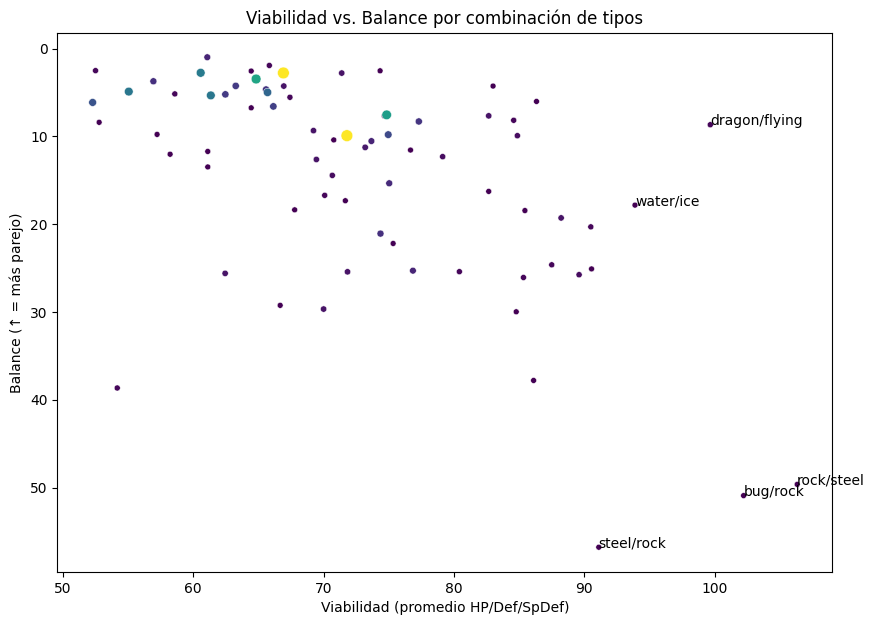

In [111]:
plt.figure(figsize=(10, 7))

sns.scatterplot(data=defensa_tipos, x='viabilidad', y='balance', size='conteo', hue='conteo', palette='viridis', legend=False)

plt.gca().invert_yaxis()  # menos desviación = más arriba = mejor balance
plt.title('Viabilidad vs. Balance por combinación de tipos')
plt.xlabel('Viabilidad (promedio HP/Def/SpDef)')
plt.ylabel('Balance (↑ = más parejo)')

# Etiquetamos las mejores combinaciones
for _, row in top_viables.head(5).iterrows():
    plt.annotate(f"{row['type1']}/{row['type2']}", (row['viabilidad'], row['balance']))

plt.show()

Podemos observar que la mejor opción Balance vs Viabilidad es la combinación dragon/flying (normalmente asociado a gran parte de pokemones pseudo-legendarios).

## **3. Economía del Juego (Tasas de captura y crianza)**

¿Qué tanta correlación matemática existe entre la dificultad para atrapar a una criatura (capture_rate), el esfuerzo de crianza (base_egg_steps) y su poder neto (base_total)?

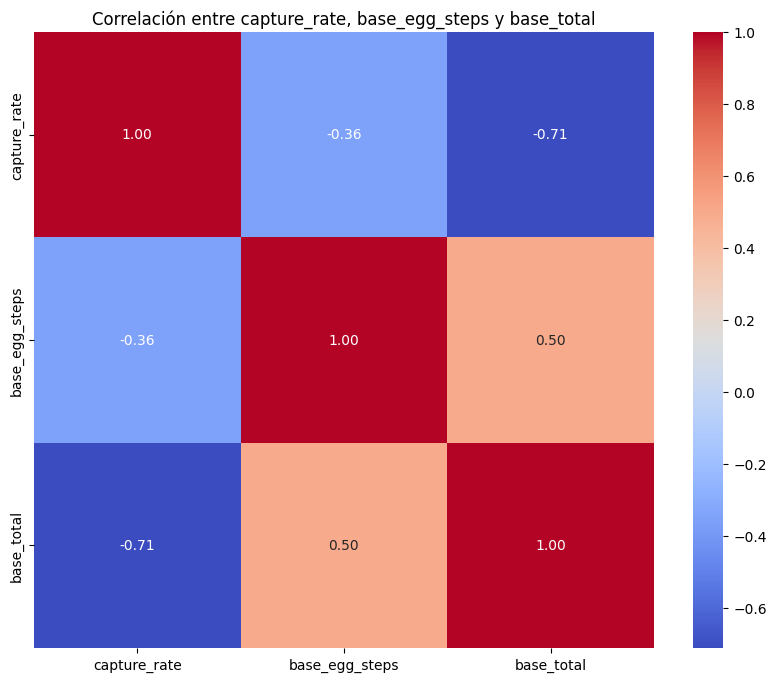

In [112]:
# Visualizamos un mapa de calor para descubrir la correlación de estas características

corr_feat = df_poke[['capture_rate', 'base_egg_steps', 'base_total']].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(corr_feat, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlación entre capture_rate, base_egg_steps y base_total')
plt.show()

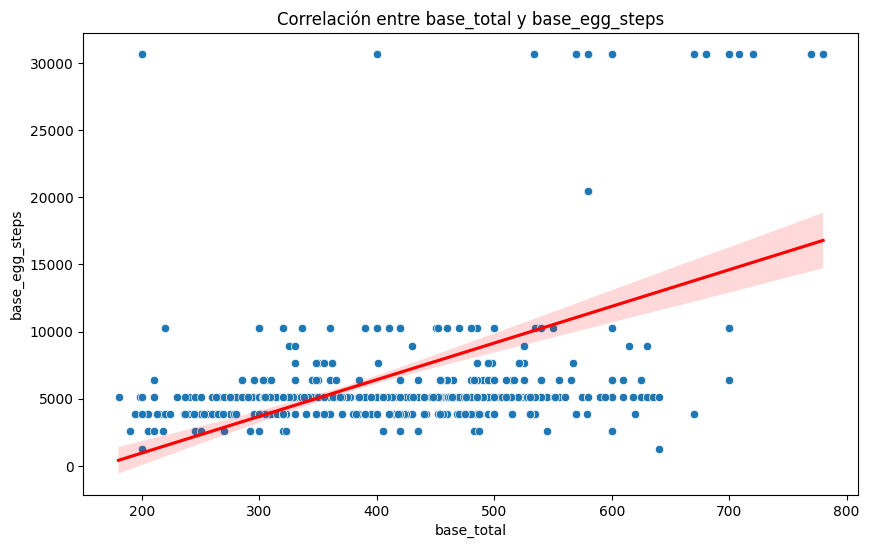

In [113]:
# Scatter plot con línea de tendencia

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_poke, x='base_total', y='base_egg_steps')
sns.regplot(data=df_poke, x='base_total', y='base_egg_steps', scatter=False, color='red')
plt.title('Correlación entre base_total y base_egg_steps')
plt.xlabel('base_total')
plt.ylabel('base_egg_steps')

plt.show()

Base Total vs Base Egg Steps:<br>Al comparar estas dos variables obtenemos un correlación del 0.50, los datos nos muestran una ligera tendencia de que mientras más puntos base tenga el pokémon, más pasos necesita para la crianza de su huevo.

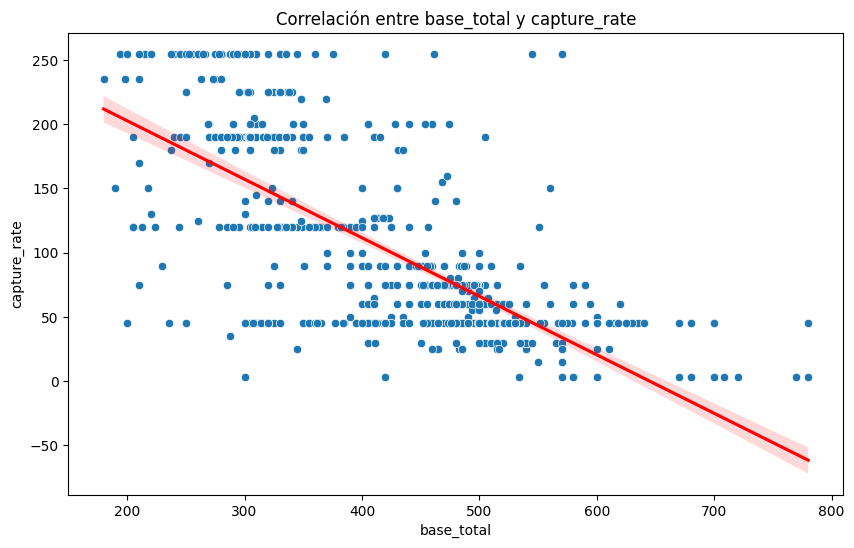

In [114]:
# Scatter plot con línea de tendencia

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_poke, x='base_total', y='capture_rate')
sns.regplot(data=df_poke, x='base_total', y='capture_rate', scatter=False, color='red')
plt.title('Correlación entre base_total y capture_rate')
plt.xlabel('base_total')
plt.ylabel('capture_rate')

plt.show()

Base Total vs Capture Rate:<br>Al comparar estas dos variables obtenemos un correlación del -0.71, los datos nos muestran una inversión en la linea de ajuste, es esperable dado que entre menor numero en el ratio de captura, más dificil es la captura de un pokémon.<br> Entre más alto el total en estadistica base, menor es el ratio de captura.

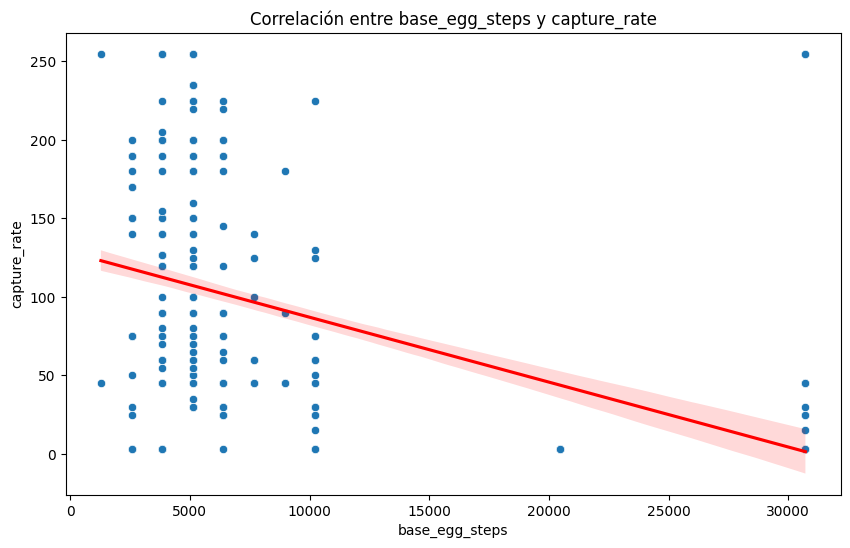

In [115]:
# Scatter plot con línea de tendencia

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_poke, x='base_egg_steps', y='capture_rate')
sns.regplot(data=df_poke, x='base_egg_steps', y='capture_rate', scatter=False, color='red')
plt.title('Correlación entre base_egg_steps y capture_rate')
plt.xlabel('base_egg_steps')
plt.ylabel('capture_rate')

plt.show()

Base Total vs Capture Rate:<br>La correlación más baja con -0.36 (ya que tomamos de nueva cuenta el ratio de captura) los datos nos muestran una vez más la inversión en la linea de ajuste.<br> Entre más pasos base de crianza tenga un pokémon, su ratio de captura se reduce.

## **4. Distribución de Roles Ocultos**

Si analizamos variables como Velocidad (speed) vs. Ataque (attack/sp_attack), ¿qué tipos elementales dominan el rol de atacantes rápidos frente a defensores lentos?

In [116]:
# Clasificar por cuadrantes usando la mediana

mediana_speed = df_poke['speed'].median()
df_poke['atk_max'] = df_poke[['attack', 'sp_attack']].max(axis=1)
mediana_atk = df_poke['atk_max'].median()

def clasificar_rol(row):
    if row['speed'] >= mediana_speed and row['atk_max'] >= mediana_atk:
        return 'Atacante rápido'
    elif row['speed'] < mediana_speed and row['atk_max'] < mediana_atk:
        return 'Defensor lento'
    elif row['speed'] >= mediana_speed:
        return 'Rápido pero débil'
    else:
        return 'Fuerte pero lento'

df_poke['rol'] = df_poke.apply(clasificar_rol, axis=1)
df_poke['rol'].value_counts()

,count
rol,
Atacante rápido,280
Defensor lento,247
Fuerte pero lento,151
Rápido pero débil,123


Se hizo uso de la mediana de cada variable como linea divisora, así "rápido" y
"lento" quedan definidos relativo al resto del dataset

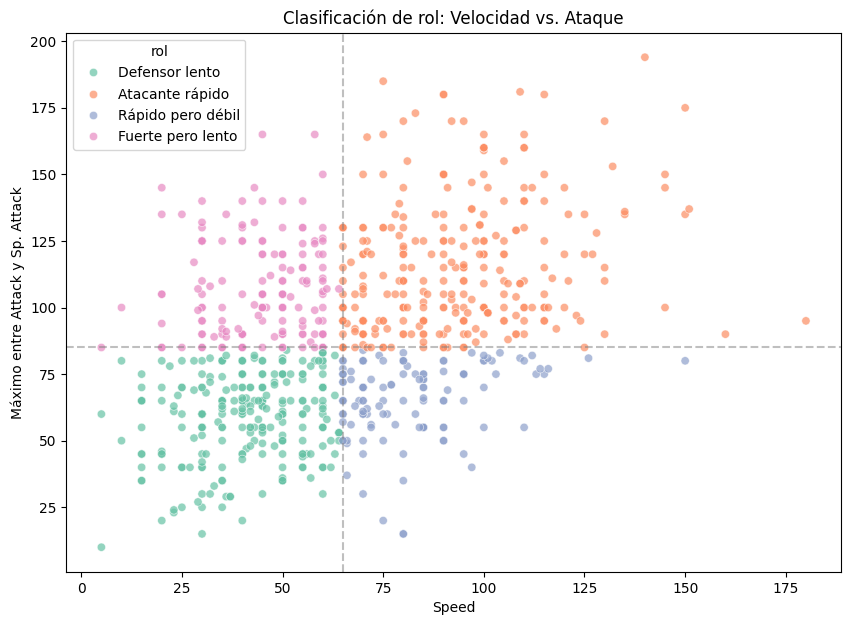

In [117]:
# Visualiza el cuadrante completo

plt.figure(figsize=(10, 7))

sns.scatterplot(data=df_poke, x='speed', y='atk_max', hue='rol', palette='Set2', alpha=0.7)
plt.axvline(mediana_speed, color='gray', linestyle='--', alpha=0.5)
plt.axhline(mediana_atk, color='gray', linestyle='--', alpha=0.5)

plt.title('Clasificación de rol: Velocidad vs. Ataque')
plt.xlabel('Speed')
plt.ylabel('Máximo entre Attack y Sp. Attack')
plt.show()

In [118]:
tabla_roles = pd.crosstab(df_poke['type1'], df_poke['rol'], normalize='index') * 100
tabla_roles = tabla_roles.round(1)

# Ordenamos por el rol que más te interesa destacar
print("Tipos con mayor % de Atacantes rápidos:")
print(tabla_roles.sort_values(by='Atacante rápido', ascending=False).head(5))

print("\nTipos con mayor % de Defensores lentos:")
print(tabla_roles.sort_values(by='Defensor lento', ascending=False).head(5))

Tipos con mayor % de Atacantes rápidos:
rol      Atacante rápido  Defensor lento  Fuerte pero lento  Rápido pero débil
type1                                                                         
flying              66.7            33.3                0.0                0.0
dragon              59.3            22.2               11.1                7.4
dark                48.3            17.2               17.2               17.2
psychic             47.2            26.4               11.3               15.1
fire                44.2            15.4               17.3               23.1

Tipos con mayor % de Defensores lentos:
rol     Atacante rápido  Defensor lento  Fuerte pero lento  Rápido pero débil
type1                                                                        
fairy              27.8            44.4               22.2                5.6
poison             31.2            40.6                9.4               18.8
bug                33.3            40.3               

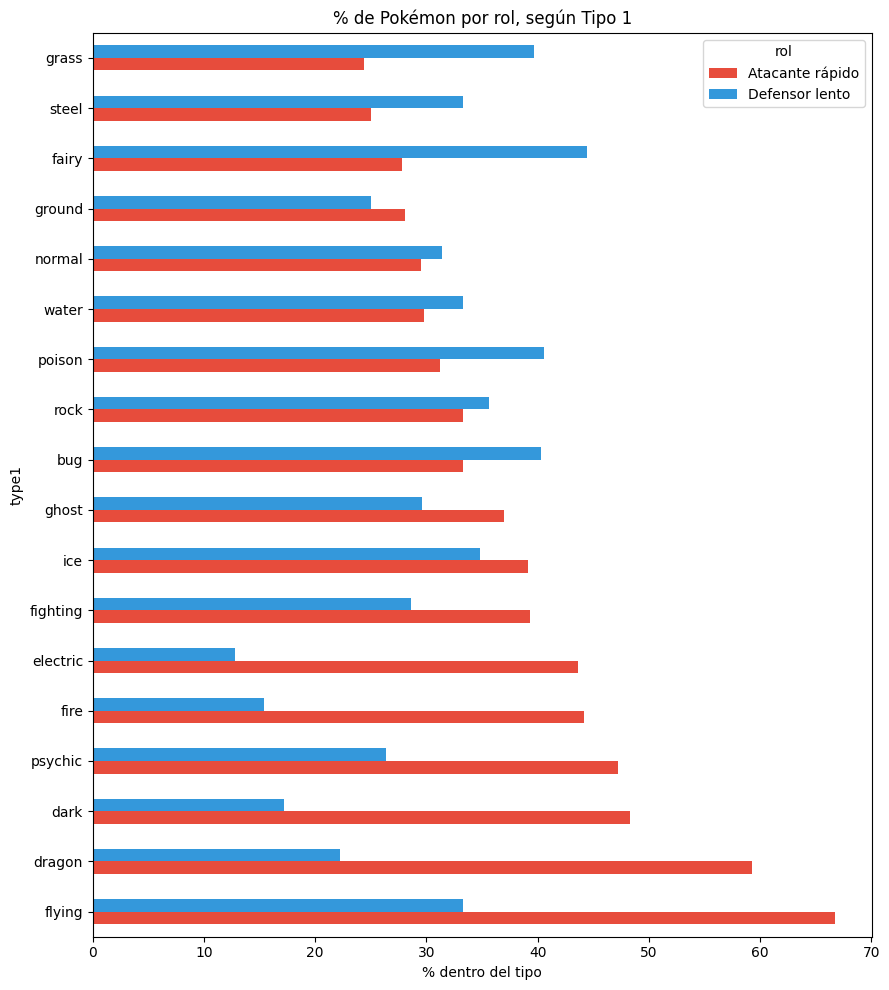

In [119]:
# Visualización de forma directa

tabla_roles[['Atacante rápido', 'Defensor lento']].sort_values(
    by='Atacante rápido', ascending=False
).plot(kind='barh', figsize=(9, 10), color=['#e74c3c', '#3498db'])
plt.title('% de Pokémon por rol, según Tipo 1')
plt.xlabel('% dentro del tipo')
plt.tight_layout()
plt.show()

# **Modelos de Machine Learning**

## **Modelo 1: Clasificación (Aprendizaje Supervisado)**

Objetivo: Predecir si un Pokémon es Legendario (is_legendary).

Justificación de negocio: Ayuda a auditar si los parámetros de diseño de una nueva criatura cruzan el umbral para ser clasificada como "Legendaria" o si está demasiado rota (overpowered) para ser una criatura normal.

Features clave: base_total, catch_rate, base_egg_steps, height_m, weight_kg.

### *Primer intento — detección de Data Leakage*

En un primer entrenamiento, utilizando `base_total`, `capture_rate`, `base_egg_steps`, `height_m` y `weight_kg` como features, el modelo obtuvo un accuracy, precision, recall, F1 y ROC AUC de 1.0, sin ningún error en la matriz de confusión.

**R =** Un resultado perfecto en todas las métricas es una señal de alerta, no de éxito — casi siempre indica **data leakage**. Al revisar las importancias, se confirmó la sospecha: `base_egg_steps` (0.49) y `capture_rate` (0.28) dominaban el modelo. Ambas variables no son consecuencia estadística del poder del Pokémon, sino **reglas de diseño del juego que casi definen directamente si un Pokémon es legendario** (los legendarios tienen, por diseño, capture_rate mínimo y base_egg_steps máximo, ya que no se reproducen normalmente). El modelo no estaba prediciendo el estatus legendario a partir de atributos de poder — estaba leyendo un proxy casi directo de la etiqueta.

### *Segundo intento — modelo corregido*

In [129]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

X = df_poke[['base_total', 'height_m', 'weight_kg']]
y = df_poke['is_legendary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [130]:
accuracy = accuracy_score(y_test, y_pred)                                 # Calcula el porcentaje de predicciones correctas sobre el total de datos.
precision = precision_score(y_test, y_pred)                               # De todo lo que el modelo dijo que era positivo, ¿cuánto era correcto realmente? (Se enfoca en evitar falsos positivos).
recall = recall_score(y_test, y_pred)                                     # De todo lo que en realidad era positivo en la vida real, ¿cuánto logró encontrar el modelo? (Se enfoca en evitar falsos negativos).
f1 = f1_score(y_test, y_pred)                                             # Da la media armónica entre la precisión y el recall, ideal para clases desbalanceadas.
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])        # Evalúa la capacidad del modelo para separar las clases usando probabilidades.
conf_matrix = confusion_matrix(y_test, y_pred)                            # Muestra los aciertos y errores en una tabla de 2x2 (verdaderos/falsos positivos y negativos).

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'ROC AUC Score: {roc_auc}')
print(f'Confusion Matrix:\n{conf_matrix}')

Accuracy: 0.9565217391304348
Precision: 0.8235294117647058
Recall: 0.7777777777777778
F1 Score: 0.8
ROC AUC Score: 0.9574592074592074
Confusion Matrix:
[[140   3]
 [  4  14]]


Se reentrenó el modelo eliminando `capture_rate` y `base_egg_steps`, dejando únicamente `base_total`, `height_m` y `weight_kg` como features.

| Métrica | Valor |
|---|---|
| Accuracy | 0.957 |
| Precision | 0.824 |
| Recall | 0.778 |
| F1 Score | 0.800 |
| ROC AUC | 0.957 |

**R =** Tras eliminar las variables con leakage, el modelo pasó de un resultado perfecto (y poco creíble) a métricas realistas y defendibles. Con solo 18 Pokémon legendarios en el set de prueba frente a 143 no-legendarios (clase desbalanceada), el accuracy por sí solo es poco informativo — por eso el F1 (0.80) y el ROC AUC (0.957) son mejores indicadores del desempeño real del modelo. Las importancias muestran que `base_total` (0.56) es la variable más influyente, seguida de `weight_kg` (0.23) y `height_m` (0.21) — un patrón mucho más creíble, ya que refleja que los Pokémon legendarios tienden a ser física y estadísticamente más grandes, sin depender de una regla de diseño casi-explícita del juego.

Dado el objetivo de negocio (auditar si el diseño de una nueva criatura la hace demasiado poderosa para ser un Pokémon normal), el **recall** es la métrica más relevante: un falso negativo (un Pokémon "roto" clasificado como normal) es más costoso para el balanceo del juego que un falso positivo. Con un recall de 0.778, el modelo aún deja escapar aproximadamente 1 de cada 5 legendarios reales — una oportunidad de mejora futura (por ejemplo, ajustando el umbral de decisión o probando técnicas de balanceo de clases como SMOTE).

In [131]:
# Importancias

importancias_forest = pd.Series(model.feature_importances_, index=X.columns)
print(importancias_forest.sort_values(ascending=False))

base_total    0.556023
weight_kg     0.229079
height_m      0.214898
dtype: float64


## **Modelo 2: Clustering para Arquetipos Competitivos (Aprendizaje No Supervisado)**

Objetivo: Agrupar automáticamente a los Pokémon en "Tiers" o roles competitivos (ej. Physical Sweepers, Special Walls, Tanks, Glass Cannons) sin depender de sus etiquetas de tipo.

Justificación de negocio: Permite a los jugadores o analistas descubrir sinergias ocultas para la composición de sus equipos y encontrar sustitutos viables para Pokémon populares (encontrar la versión "económica" de un atacante físico potente).

Features clave: Las 6 estadísticas de combate (hp, attack, defense, sp_attack, sp_defense, speed).

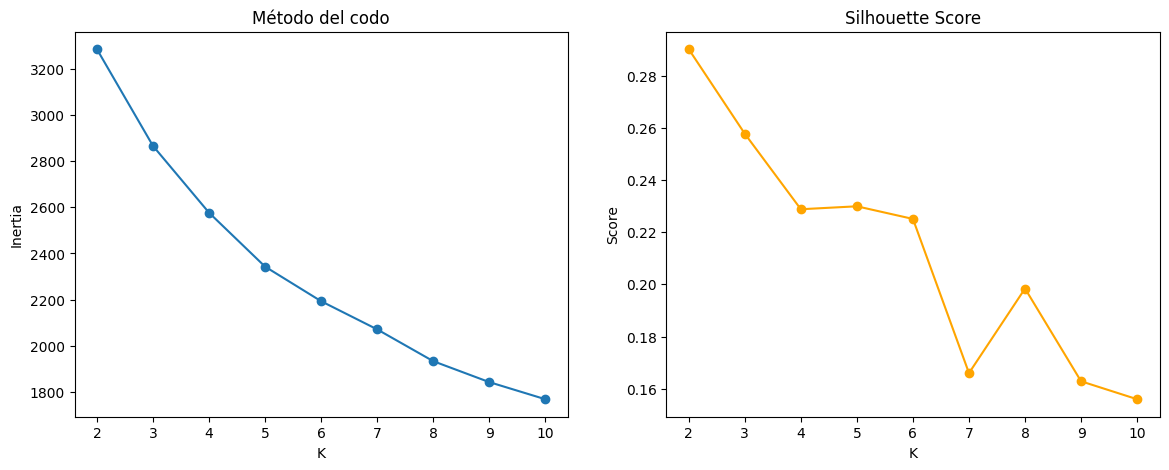

In [123]:
# Importamos la biblioteca de clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Seleccionamos solo los stats de combate
features = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']
X = df_poke[features].copy()

# Estandarizamos los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#
inertias = []
silhouettes = []
rango_k = range(2, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(rango_k, inertias, marker='o')
ax[0].set_title('Método del codo')
ax[0].set_xlabel('K')
ax[0].set_ylabel('Inertia')

ax[1].plot(rango_k, silhouettes, marker='o', color='orange')
ax[1].set_title('Silhouette Score')
ax[1].set_xlabel('K')
ax[1].set_ylabel('Score')
plt.show()


In [124]:
# Entrenamos el modelo final con K=5
k_optimo = 5

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_poke['cluster'] = kmeans.fit_predict(X_scaled)

print(df_poke['cluster'].value_counts().sort_index())

cluster
0    115
1     95
2    171
3    295
4    125
Name: count, dtype: int64


Con el K óptimo definido (K=5), entrenamos el modelo final y analizamos el perfil promedio de stats de cada cluster para asignarle un arquetipo competitivo interpretable:

| Cluster | Tamaño | Perfil dominante | Arquetipo |
|---|---|---|---|
| 3 | 295 | Todas las stats bajas, sin picos | Pokémon débiles / early-game |
| 1 | 95 | Defense muy alta (122.4), speed baja | Wall físico |
| 2 | 171 | Speed dominante (94.5) | Sweeper rápido |
| 0 | 115 | HP dominante (104.0) | Tanque bulky |
| 4 | 125 | Sp.Attack, Attack y Sp.Defense altos | Élite / pseudo-legendario |

In [125]:
# Perfil promedio de cada cluster — la parte clave para ponerle nombre a cada arquetipo
perfil_clusters = df_poke.groupby('cluster')[features].mean().round(1)
perfil_clusters

,hp,attack,defense,sp_attack,sp_defense,speed
cluster,,,,,,
0,104.0,92.5,76.1,76.6,77.2,55.6
1,65.2,88.2,122.4,63.8,90.6,47.3
2,67.1,81.4,67.0,76.9,71.7,94.5
3,50.0,53.8,50.8,47.8,48.4,49.3
4,86.9,108.4,93.3,120.0,102.2,92.3


**R =** El clustering logró segmentar de forma coherente desde Pokémon de bajo poder general (cluster 3, el grupo más numeroso, lo cual tiene sentido dado que la mayoría de especies base no compiten a nivel élite) hasta Pokémon de alto rendimiento en múltiples stats (cluster 4). Los clusters 0, 1 y 2 representan roles especializados y diferenciables entre sí: bulk por HP, defensa pura, y velocidad, respectivamente.

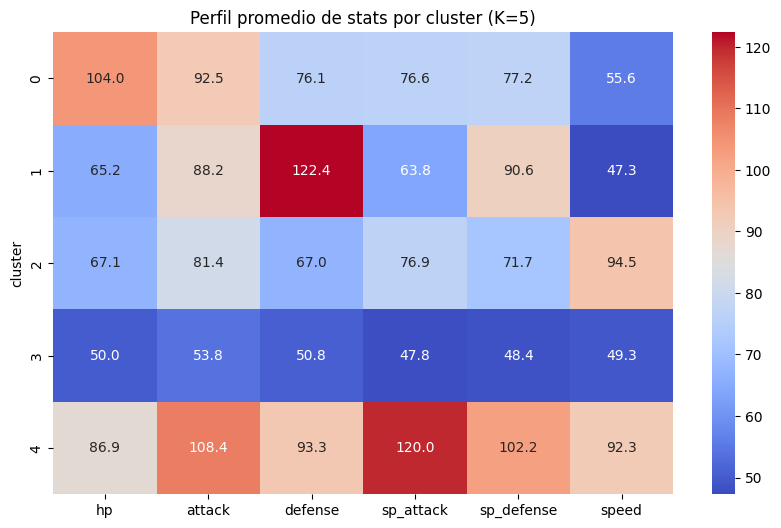

In [126]:
# Heatmap para comparar los perfiles visualmente
plt.figure(figsize=(10, 6))
sns.heatmap(perfil_clusters, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Perfil promedio de stats por cluster (K=5)')
plt.show()

### *Validación con Pokémon icónicos*

In [128]:
# Validación cualitativa con Pokémon icónicos conocidos por su rol competitivo
df_poke[df_poke['name'].isin(['Mewtwo', 'Blissey', 'Deoxys Speed Forme', 'Shuckle', 'Ninetales', 'Slaking'])][
    ['name', 'cluster'] + features
]

,name,cluster,hp,attack,defense,sp_attack,sp_defense,speed
37,Ninetales,2,73,67,75,81,100,109
149,Mewtwo,4,106,150,70,194,120,140
212,Shuckle,1,20,10,230,10,230,5
241,Blissey,0,255,10,10,75,135,55
288,Slaking,4,150,160,100,95,65,100


Para validar cualitativamente si los clusters reflejan roles reales del metagame, verificamos dónde cayeron Pokémon con roles competitivos ampliamente conocidos:

- **Mewtwo → Cluster 4 (Élite):** consistente, tiene stats altísimas en casi todas las categorías.
- **Slaking → Cluster 4 (Élite):** consistente, Attack 160 y HP 150 son valores de gama alta.
- **Ninetales → Cluster 2 (Sweeper rápido):** consistente, su Speed (109) domina su perfil de stats.
- **Shuckle → Cluster 1 (Wall):** parcialmente consistente. Shuckle tiene Defense y Sp.Defense extremas (230 en ambas), pero el cluster 1 solo capturó bien el eje de defensa física — evidencia de que K-Means, al basarse en distancia euclidiana, no siempre agrupa perfectamente a Pokémon con picos extremos en dos stats simultáneamente.
- **Blissey → Cluster 0 (Tanque bulky):** este caso es el más revelador. Blissey tiene HP 255 (extremo) pero Attack 10 y Defense 10 (extremadamente bajos), un perfil muy asimétrico. Terminó en el cluster 0 porque su HP altísimo domina la distancia euclidiana hacia ese centroide, aunque su perfil real de "pared especial pura" no coincide del todo con el promedio del cluster (Attack 92.5).

**R =** La validación confirma que el modelo identifica correctamente los arquetipos "extremos" (élite, débiles), pero tiene una limitación esperada con Pokémon "especialistas" que son extremos en solo 1-2 stats y bajos en el resto (como Blissey o Shuckle). Esto no es un error del modelo, sino una limitación conocida de K-Means: al asumir clusters esféricos basados en distancia euclidiana, tiende a agrupar mejor perfiles "balanceadamente altos o bajos" que perfiles muy asimétricos.

### *Visualización con PCA*

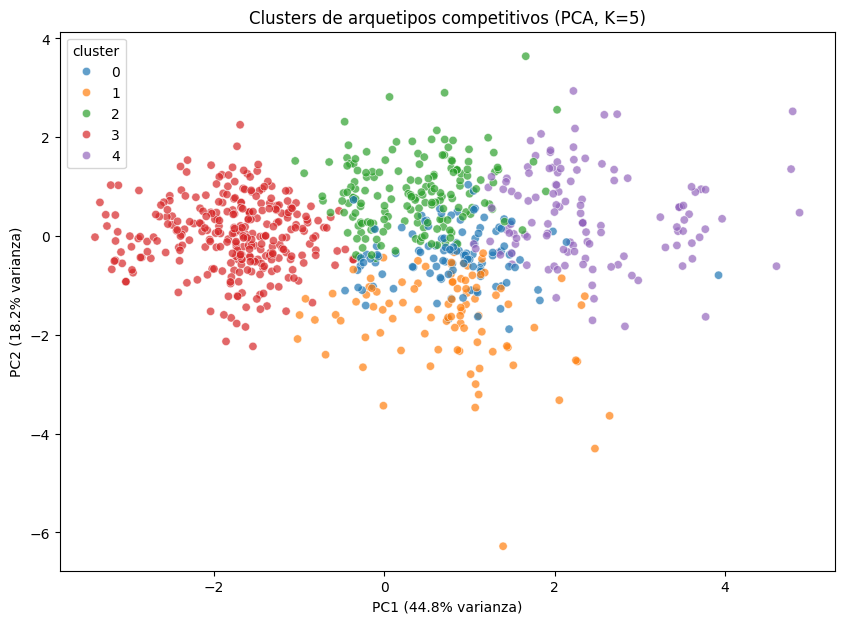

In [127]:
# Reducción a 2D con PCA para visualizar la separación de clusters
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_poke['pca1'] = X_pca[:, 0]
df_poke['pca2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_poke, x='pca1', y='pca2', hue='cluster', palette='tab10', alpha=0.7)
plt.title('Clusters de arquetipos competitivos (PCA, K=5)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
plt.show()

**R =** La proyección en 2 componentes principales (44.8% + 18.2% de varianza explicada) muestra que el cluster 3 (Pokémon débiles) está claramente separado del resto, lo cual es fácil de discriminar. Sin embargo, los clusters 0, 1, 2 y 4 presentan un solapamiento notable en el centro del gráfico. Este resultado es consistente con el Silhouette Score relativamente bajo obtenido durante la selección de K (~0.23): el dataset tiene un grupo claramente distinto (Pokémon débiles) y luego un continuo de Pokémon competitivos, donde los límites entre roles son más un espectro que categorías completamente discretas — un hallazgo coherente con cómo se diseñan las stats de Pokémon en la práctica, de forma progresiva y no por bloques cerrados.

# **Conclusión General del Proyecto**

**Objetivo de negocio:** Optimizar el balanceo del juego y descubrir ventajas estadísticas para la composición de equipos competitivos mediante el análisis de atributos y el modelado de datos.

Este proyecto abordó el objetivo desde dos frentes complementarios: un **análisis exploratorio** que respondió 4 preguntas de negocio sobre el diseño y la economía del juego, y un **modelado predictivo** que abordó tanto un problema de clasificación como uno de segmentación no supervisada.

## Resumen de hallazgos — Análisis Exploratorio

**1. Power Creep:** El Base Stat Total promedio no crece de forma lineal entre generaciones. Se observó un salto abrupto entre la 3ra y 4ta generación (coincidiendo con la introducción de más legendarios y megaevoluciones), seguido de un descenso en la 5ta y un crecimiento gradual después. **Implicación de negocio:** el equipo de diseño debería vigilar de cerca los lanzamientos de nuevos legendarios/megaevoluciones, ya que son el principal motor de inflación de poder, más que el paso del tiempo en sí.

**2. Sinergia y Tipología:** Existen combinaciones de tipos únicas (frecuencia = 1) que representan nichos de diseño poco explorados. Al evaluar viabilidad (promedio de HP/Defense/Sp.Defense) y balance (baja desviación entre esas 3 stats) en combinaciones con al menos 3 Pokémon, se identificaron las combinaciones de tipos más sólidas defensivamente. **Implicación de negocio:** estas combinaciones son candidatas atractivas para el diseño de nuevas criaturas con rol defensivo bien fundamentado estadísticamente.

**3. Economía del juego:** Existe una correlación clara entre `base_total`, `capture_rate` y `base_egg_steps` — los Pokémon más poderosos son sistemáticamente más difíciles de capturar y de criar. **Implicación de negocio:** el sistema de captura/crianza ya funciona como un mecanismo de balanceo económico dentro del propio juego, penalizando el acceso a Pokémon fuertes con mayor esfuerzo requerido.

**4. Distribución de roles ocultos:** Clasificando a los Pokémon en cuadrantes de Velocidad vs. Ataque (usando la mediana como punto de corte), se identificaron los tipos elementales que dominan el rol de "atacante rápido" frente a "defensor lento". **Implicación de negocio:** esta segmentación permite anticipar qué tipos elementales tienden a definir el ritmo del meta-juego (quién ataca primero) frente a los que sostienen la defensa.

## Resumen de hallazgos — Modelado

**Modelo 1 (Clasificación — Random Forest):** El primer intento de predecir el estatus legendario arrojó un resultado perfecto (accuracy = 1.0), lo cual se identificó como **data leakage**: las variables `capture_rate` y `base_egg_steps` son casi una definición directa de "legendario" por diseño del juego, no atributos predictivos genuinos. Tras eliminarlas y reentrenar solo con `base_total`, `height_m` y `weight_kg`, se obtuvo un modelo realista y defendible (F1 = 0.80, ROC AUC = 0.957), capaz de auditar si el diseño estadístico de una nueva criatura la acerca al perfil de un legendario.

**Modelo 2 (Clustering — K-Means):** Utilizando únicamente las 6 stats de combate, se identificaron 5 arquetipos competitivos (débiles, wall físico, sweeper rápido, tanque bulky, élite) sin depender de las etiquetas de tipo. La validación cualitativa con Pokémon icónicos confirmó que el modelo identifica bien los perfiles "extremos balanceados" (Mewtwo, Slaking), pero tiene una limitación esperada con "especialistas puros" de picos muy asimétricos (Blissey, Shuckle) — una limitación inherente a K-Means y su supuesto de clusters esféricos, no un error del análisis.

## Conclusión final

El análisis confirma que el diseño de Pokémon sigue patrones estadísticos consistentes y explotables: el poder general está fuertemente correlacionado con la dificultad de obtención, existen roles competitivos claramente diferenciables a partir de solo 6 variables de combate, y es posible auditar automáticamente si una nueva criatura se acerca al perfil de un legendario.

Ambos modelos, sin embargo, comparten una lección metodológica central: los resultados "demasiado perfectos" (accuracy = 1.0, o el mejor silhouette score en K=2) no deben tomarse a valor nominal sin antes verificar qué los está generando — en un caso resultó ser leakage, en el otro una simplificación excesiva del problema (agrupar solo "fuerte vs. débil"). Detectar y corregir ambos casos fue tan valioso para el proyecto como los resultados finales en sí.

**Próximos pasos sugeridos para un entorno de producción:**
- Probar `SMOTE` u otras técnicas de balanceo de clases para mejorar el recall del Modelo 1.
- Probar `DBSCAN` o `Gaussian Mixture Models` para el Modelo 2, dado que no asumen clusters esféricos y podrían representar mejor a los "especialistas puros".
- Incorporar datos de generaciones más recientes (el dataset actual se detiene en la Gen 7), para validar si los hallazgos de Power Creep se mantienen vigentes.